*Prof. Stefano Diciotti*  
*University of Bologna*

---

**Academic Year:** 2025/2026  
**Student Name:** Reza Jokarian  
**Course:** Artificial Intelligence for Medicine

# Project Title : Diabetes Prediction from Clinical Data

This project aims to predict whether a patient has diabetes using routine clinical measurements from the Pima Indians Diabetes dataset. Early detection is important because it can trigger follow‑up tests, closer monitoring, and preventive lifestyle changes.

The main challenges with this dataset are: some values are missing or physiologically impossible, the two classes (diabetes vs no diabetes) are not equally represented, and the sample size is limited. Because of this, we focus on building models that are both reliable and easy to interpret. We use careful validation and evaluation metrics that are meaningful in a medical context, so that the results can support real clinical decisions.



# Project Overview Summary

This project is organized into five main parts:

1. **Data Loading and Preprocessing**  
   First, we load the dataset, separate the input features from the target variable, and replace impossible zero values with missing values so they can be handled properly later.

2. **Exploratory Data Analysis**  
   Next, we explore the data to understand class imbalance, feature distributions, possible outliers, and relationships between variables.

3. **Model defenition and Validation**  
   We then create three machine-learning pipelines — logistic regression, random forest, and XGBoost — and compare them using nested cross-validation to get a fair estimate of performance.

4. **Final Model Selection**  
   After comparing the models, we choose the one with the best overall performance and retrain it on the full dataset using the best hyperparameters.

5. **Final Evaluation and Interpretation**  
   Finally, we evaluate the selected model in more detail using the ROC curve, threshold tuning, confusion matrix, and feature importance, so that the results are both useful and easy to understand.

# 1. **Data Loadig and Preprocessing**


The first cell loads the Pima Indians Diabetes dataset from GitHub, sets a fixed random seed for reproducibility, and separates features (X) from the target (Y). It replaces physiologically impossible zero values in selected clinical features with NaN to handle them as missing data later, and prints basic dataset shape, class distribution, and feature names to the structure.

In [42]:
# Setup and Data Loading from github

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_STATE = 42

url = 'https://raw.githubusercontent.com/Reza-Jokarian/AIForMedicine-FinalProject/main/Data/diabetes.csv'
df = pd.read_csv(url)

cols_with_missing_values = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_missing_values] = df[cols_with_missing_values].replace(0, np.nan)
print(df.head(10))
X = df.drop(columns=['Outcome'])
Y = df['Outcome']

print("Dataset shape:\n X shape: ", X.shape, "\nY shape:", Y.shape)
print("\nClass distribution:\n",Y.value_counts())
print("\nFeature names:\n",X.columns)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0      NaN  33.6   
1            1     85.0           66.0           29.0      NaN  26.6   
2            8    183.0           64.0            NaN      NaN  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   
5            5    116.0           74.0            NaN      NaN  25.6   
6            3     78.0           50.0           32.0     88.0  31.0   
7           10    115.0            NaN            NaN      NaN  35.3   
8            2    197.0           70.0           45.0    543.0  30.5   
9            8    125.0           96.0            NaN      NaN   NaN   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   2

## 2. Exploratory Data Analysis

Next, the class distribution of the target variable are visualized using bar and pie charts, showing both the absolute counts and percentages of non‑diabetic (class 0) and diabetic (class 1) samples. Looking at the results, the class imbalance visible (65.1% non‑diabetic vs 34.9% diabetic).

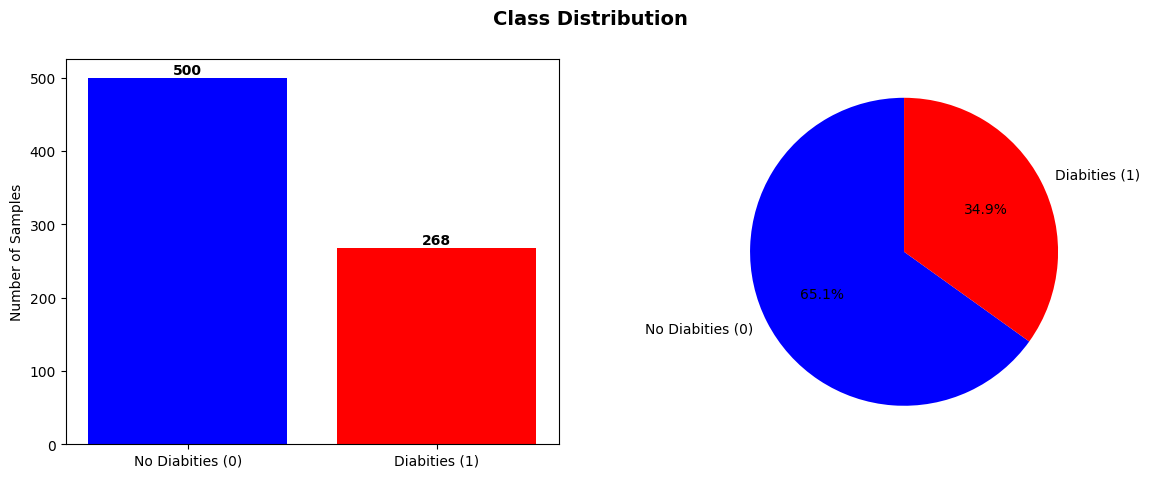

In [43]:
# Class distribution plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_count = Y.value_counts()


# Bar chart

axes[0].bar(['No Diabities (0)', 'Diabities (1)'],
            [class_count[0], class_count[1]],
            color=['blue', 'red'])
axes[0].set_ylabel('Number of Samples')
axes[0].text(0, class_count[0] + 5, str(class_count[0]), ha='center', fontweight='bold')
axes[0].text(1, class_count[1] + 5, str(class_count[1]), ha='center', fontweight='bold')


# pie chart
axes[1].pie([class_count[0], class_count[1]],
            labels=['No Diabities (0)', 'Diabities (1)'],
            colors=['blue', 'red'],
            autopct='%1.1f%%', startangle=90)

plt.suptitle('Class Distribution', fontsize=14, fontweight='bold')
plt.show()

Next I have compared the distributions of all input features for non‑diabetic (0) vs diabetic (1) patients using overlaid histograms. It shows that some features (especially Glucose and BMI) tend to be higher in diabetic cases, suggesting they are likely to be strong predictors in this dataset, while others show more overlap and may be less important..

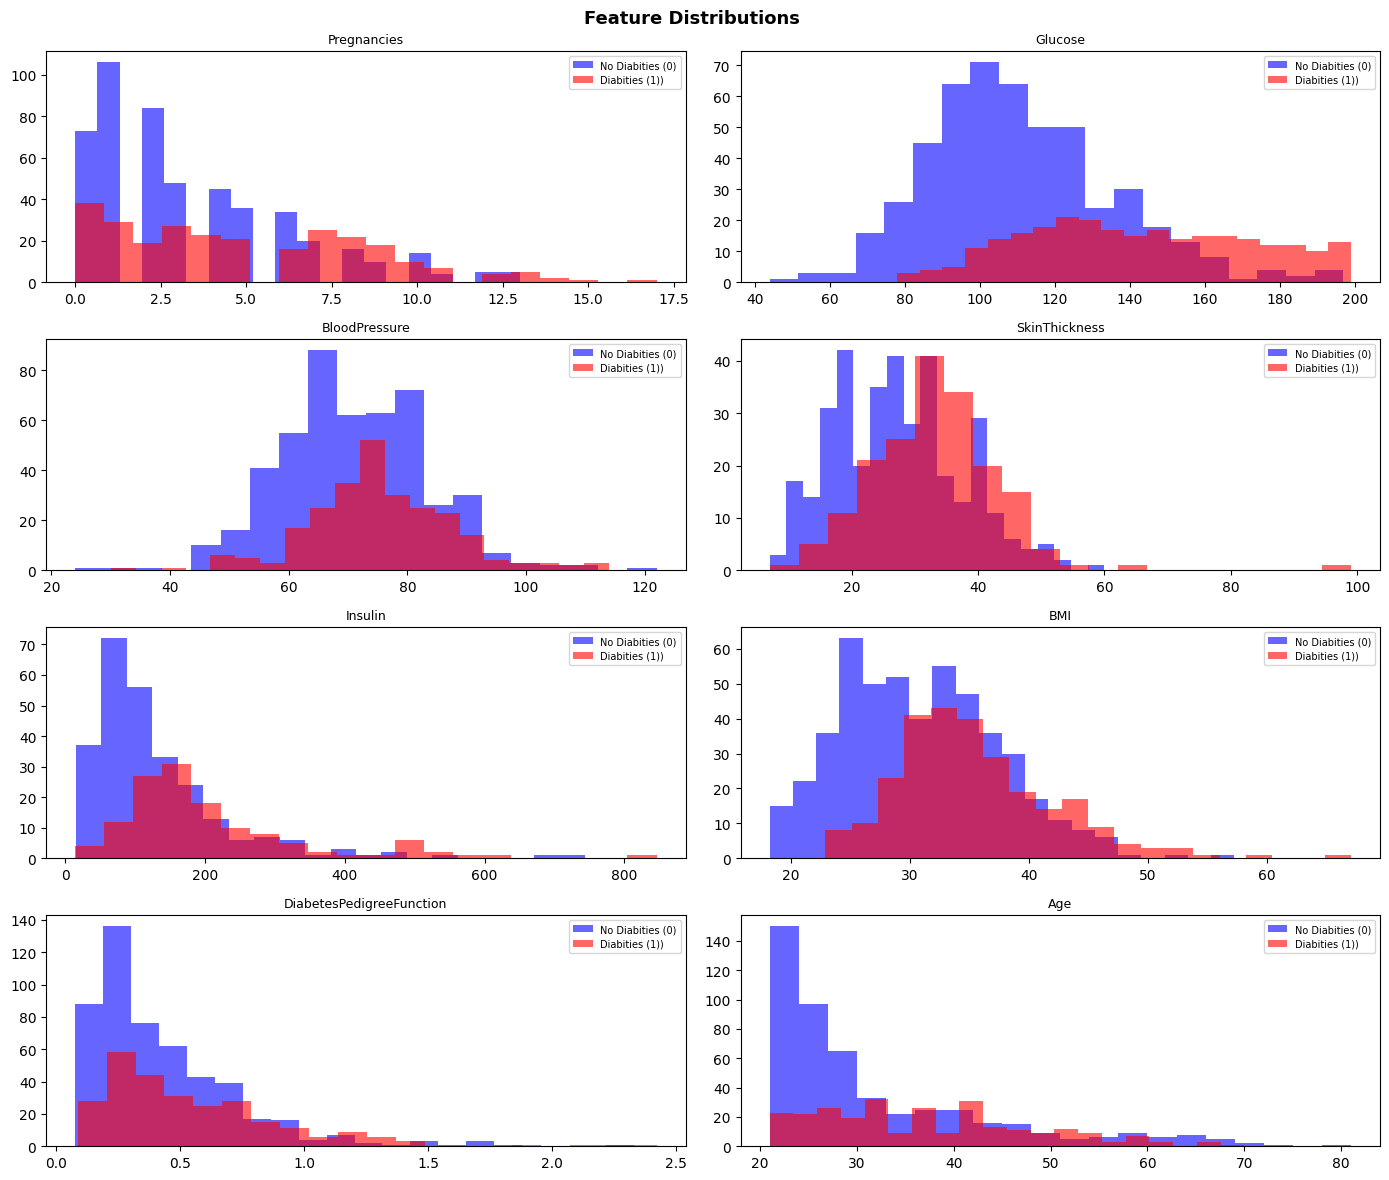

In [44]:
#Feature distributions (8 features)

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()
for i, col in enumerate(X.columns):
    axes[i].hist(X[col][Y==0], bins=20, alpha=0.6, color='blue', label='No Diabities (0)')
    axes[i].hist(X[col][Y==1], bins=20, alpha=0.6, color='red', label='Diabities (1))')
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)
plt.suptitle('Feature Distributions ', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

This cell computes the correlation matrix between all input features and visualizes it as a heatmap. It also counts how many feature pairs have very high correlation (|r| > 0.9), confirming that in this dataset there are no strongly collinear features. This helps justify using all features in the pipeline without additional decorrelation steps.

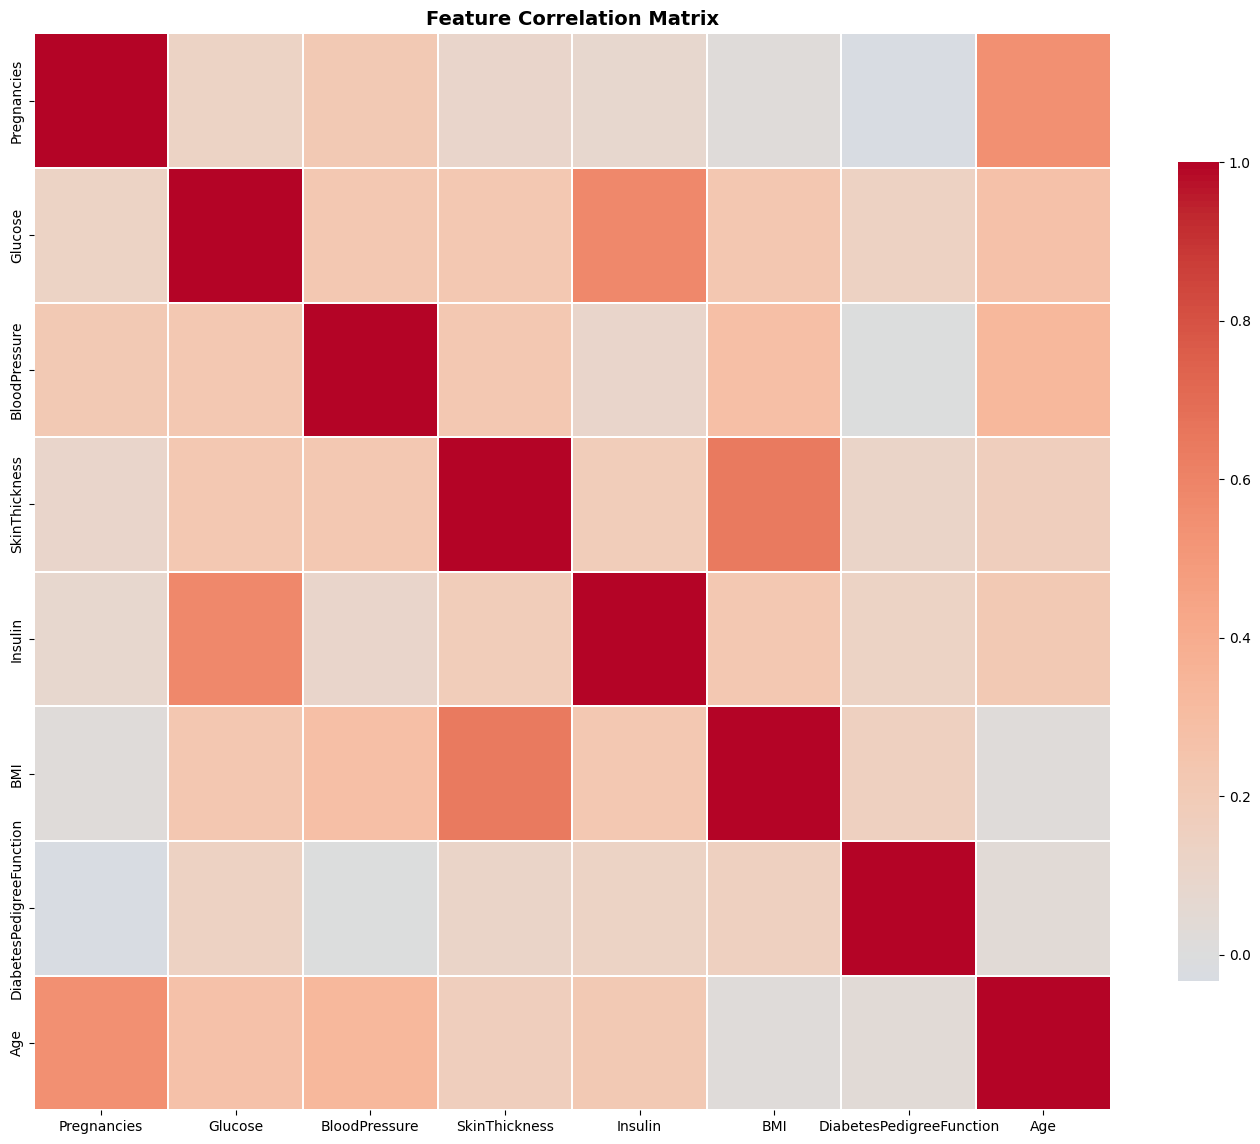


Number of highly correlated feature pairs (|r| > 0.9):  0


In [45]:
#Correlation heatmap
plt.figure(figsize=(14, 12))
corr = X.corr()
sns.heatmap(corr, cmap='coolwarm', center=0,
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.7})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("\nNumber of highly correlated feature pairs (|r| > 0.9): ", ((corr.abs() > 0.9) & (corr.abs() != 1)).sum().sum() // 2)


# 3. Model Definition & Validation

This cell defines three pipelines (logistic regression,
random forest and XGBoost) that include median imputation and feature scaling inside the pipeline to avoid data leakage. It also specifies simple hyperparameter grids for each model and sets up nested stratified cross‑validation (outer 5‑fold for unbiased performance estimation, inner 5‑fold for hyperparameter tuning), ensuring fair and leakage‑free evaluation on the imbalanced Pima diabetes dataset.

In [46]:
# Pipeline Definition

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, cross_validate, cross_val_predict
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer

# Defining pipelines and their hyperparameter grids

# Pipeline 1: Logistic Regression
pipe_lr = Pipeline([
    ('imputer',  SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=5000))
])

param_grid_lr = {
    'clf__C': [0.1, 1, 5, 10],
    'clf__class_weight': [None, 'balanced'],
    'clf__solver': ["liblinear", "lbfgs"]
}

# Pipeline 2: Random Forest
pipe_rf = Pipeline([
    ('imputer',  SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE))
])

param_grid_rf = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [5, 10, 15]
}

# Pipeline 3: XGBoost
pipe_xgb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        random_state=RANDOM_STATE, eval_metric='logloss'))
])

param_grid_xgb = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [3, 5],
    'clf__learning_rate': [0.05, 0.1]
}

# Cross-validation

# Outer CV: 5-fold stratified (performance estimation)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Inner CV: 5-fold stratified (hyperparameter tuning)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Pipelines defined: Logistic Regression, Random Forest, XGBoost')
print('StandardScaler is INSIDE each pipeline to avoid any data leakage')
print('Imputer is INSIDE each pipeline to avoid any data leakage')
print('Nested CV configured: outer=5-fold, inner=5-fold')



Pipelines defined: Logistic Regression, Random Forest, XGBoost
StandardScaler is INSIDE each pipeline to avoid any data leakage
Imputer is INSIDE each pipeline to avoid any data leakage
Nested CV configured: outer=5-fold, inner=5-fold


This cell implements nested 5×5 cross-validation for each pipeline using GridSearchCV in the inner loop and cross_validate in the outer loop. It reports mean and per-fold AUC scores and the best hyperparameters found in each outer fold, then summarizes the average performance of logistic regression, random forest, and XGBoost. This provides an unbiased estimate of model performance on the imbalanced dataset and avoids data leakage between tuning and evaluation.

In [47]:
# Nested Cross-Validation Execution



def run_nested_cv(pipeline, param_grid, model_name):

    grid_search = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        cv=inner_cv,
        refit='roc_auc',
        scoring='roc_auc',
        n_jobs=-1
    )

    nested_score = cross_validate(
        grid_search,
        X, Y,
        cv=outer_cv,
        scoring= ['roc_auc', 'accuracy', 'precision', 'recall', 'f1'],
        return_train_score=False,
        return_estimator=True,
        n_jobs=-1
    )
    print('\n',60*'#')
    print('', model_name)
    print('Mean AUC test: ', np.mean(nested_score['test_roc_auc']).round(4))
    print('Std AUC test:  ', np.std(nested_score['test_roc_auc']).round(4))
    print('Mean F1 test:  ', np.mean(nested_score['test_f1']).round(4))
    print('Mean Precision:', np.mean(nested_score['test_precision']).round(4))
    print('Mean Recall:   ', np.mean(nested_score['test_recall']).round(4))
    print('Mean Accuracy: ', np.mean(nested_score['test_accuracy']).round(4))
    print('Per-fold AUC:  ', nested_score['test_roc_auc'].round(4))
    print('Best hyperparameters per outer fold:')
    for i, est in enumerate(nested_score['estimator']):
        print(f'  Fold {i+1}: {est.best_params_}')

    return {
        'auc': nested_score['test_roc_auc'],
        'f1': nested_score['test_f1'],
        'precision': nested_score['test_precision'],
        'recall': nested_score['test_recall'],
        'accuracy': nested_score['test_accuracy']
    }

print('Nested 5x5 Cross-Validation :')

lr_scores = run_nested_cv(pipe_lr, param_grid_lr, 'Logistic Regression')
rf_scores = run_nested_cv(pipe_rf, param_grid_rf, 'Random Forest')
xgb_scores = run_nested_cv(pipe_xgb, param_grid_xgb, 'XGBoost')

results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Mean AUC': [np.mean(lr_scores['auc']), np.mean(rf_scores['auc']), np.mean(xgb_scores['auc'])],
    'F1': [np.mean(lr_scores['f1']), np.mean(rf_scores['f1']), np.mean(xgb_scores['f1'])],
    'Precision': [np.mean(lr_scores['precision']), np.mean(rf_scores['precision']), np.mean(xgb_scores['precision'])],
    'Accuracy': [np.mean(lr_scores['accuracy']), np.mean(rf_scores['accuracy']), np.mean(xgb_scores['accuracy'])],
    'Recall': [np.mean(lr_scores['recall']), np.mean(rf_scores['recall']), np.mean(xgb_scores['recall'])],
    'Std AUC': [np.std(lr_scores['auc']), np.std(rf_scores['auc']), np.std(xgb_scores['auc'])]
}).sort_values(by='Mean AUC', ascending=False)

print('\n',60*'#')
print(' FINAL SUMMARY')
print(results_df)



Nested 5x5 Cross-Validation :

 ############################################################
 Logistic Regression
Mean AUC test:  0.837
Std AUC test:   0.0212
Mean F1 test:   0.6428
Mean Precision: 0.6852
Mean Recall:    0.6233
Mean Accuracy:  0.7578
Per-fold AUC:   [0.825  0.868  0.8533 0.8306 0.8081]
Best hyperparameters per outer fold:
  Fold 1: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__solver': 'liblinear'}
  Fold 2: {'clf__C': 0.1, 'clf__class_weight': None, 'clf__solver': 'lbfgs'}
  Fold 3: {'clf__C': 0.1, 'clf__class_weight': None, 'clf__solver': 'lbfgs'}
  Fold 4: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__solver': 'lbfgs'}
  Fold 5: {'clf__C': 0.1, 'clf__class_weight': None, 'clf__solver': 'liblinear'}

 ############################################################
 Random Forest
Mean AUC test:  0.8362
Std AUC test:   0.0203
Mean F1 test:   0.6312
Mean Precision: 0.712
Mean Recall:    0.5709
Mean Accuracy:  0.7682
Per-fold AUC:   [0.8641 0.8519 0.8354 0

# 5. Final Model Selection

This cell selects the best‑performing model based on mean ROC AUC from the nested cross‑validation summary, then refits that model on the full dataset using an inner GridSearchCV to pick optimal hyperparameters. This gives a final, tuned model trained on all available samples, with performance estimates taken from the earlier nested CV so that no test information leaks into the training or tuning process.



In [48]:
print('FINAL MODEL — Retraining on Full Dataset')

# Identify best model from nested CV summary
best_model = results_df.iloc[0]['Model']
print('Best model by Mean AUC: ', best_model)
print('Mean AUC: ', results_df.iloc[0]['Mean AUC'].round(4), 'std: ', results_df.iloc[0]['Std AUC'].round(4))

# Map name to pipeline and grid
models = {
    'Logistic Regression': (pipe_lr, param_grid_lr),
    'Random Forest': (pipe_rf, param_grid_rf),
    'XGBoost': (pipe_xgb, param_grid_xgb)
}

final_pipe, final_grid = models[best_model]

# Refit on full dataset — inner CV selects hyperparameters
final_gs = GridSearchCV(
    final_pipe, final_grid,
    cv=inner_cv, scoring='roc_auc',
    refit=True, n_jobs=-1
)

final_model = final_gs.fit(X, Y)
print('chosen hyperparameter:', final_gs.best_params_.items())

print('Final model trained on all', len(X), 'samples.')



FINAL MODEL — Retraining on Full Dataset
Best model by Mean AUC:  Logistic Regression
Mean AUC:  0.837 std:  0.0212
chosen hyperparameter: dict_items([('clf__C', 0.1), ('clf__class_weight', None), ('clf__solver', 'liblinear')])
Final model trained on all 768 samples.


# 6. Final Evaluation and Interpretation

This cell evaluates the final tuned model using cross‑validated predicted probabilities, plots the ROC curve, and then searches thresholds between 0.1 and 0.5 to find the value that maximizes F1 for the diabetes class. It uses this data‑driven threshold to build the confusion matrix and compute AUC, precision, recall, accuracy, and F1, showing how the chosen operating point balances false positives and false negatives in this imbalanced screening problem

Generating plots for final model: Logistic Regression


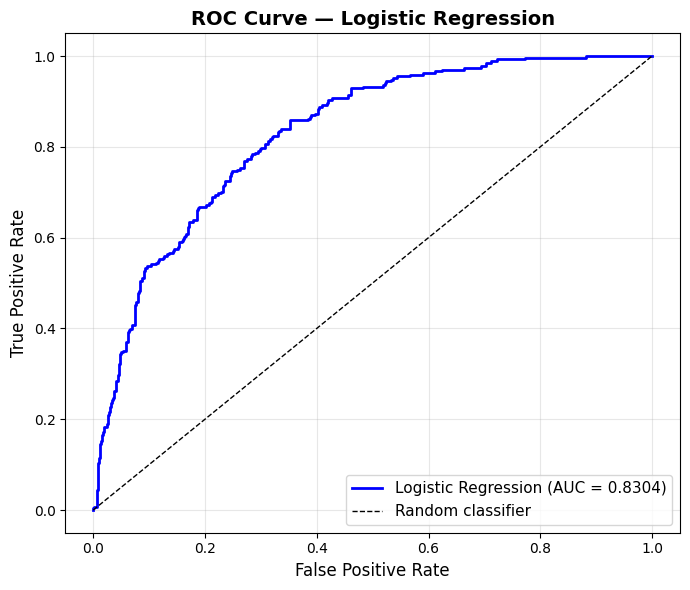


Choosing the best threshold:

Best threshold by F1: 0.31
Best F1: 0.6825

 confusion matrix for Thereshold =  0.31


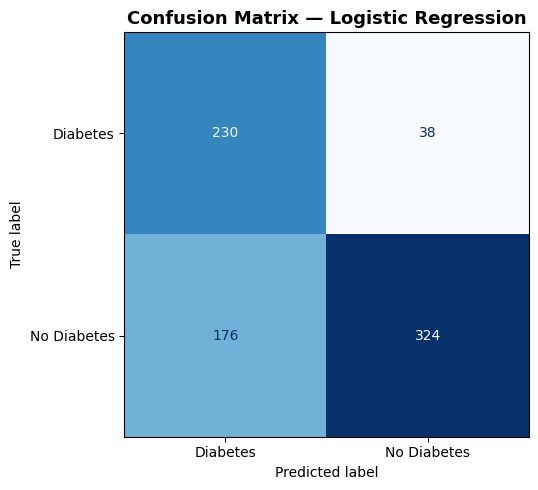

AUC:  0.8304
Classification Report:

Precision:  0.5665
Accuracy:  0.7214
Recall:  0.8582
F1:  0.6825


In [49]:
#ROC Curve + Confusion Matrix of Final Model

print("Generating plots for final model:", best_model)

# Probability scores — each sample predicted by model that never saw it

y_prob = cross_val_predict(final_model, X, Y,
                               cv=outer_cv, method='predict_proba')[:, 1]

#ROC Curve

fpr, tpr, _ = roc_curve(Y, y_prob)
auc_val = roc_auc_score(Y, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', lw=2,
         label=f'{best_model} (AUC = {auc_val.round(4)})')
plt.plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve — {best_model}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#Confusion Matrix
#choosing the threshold
print('\nChoosing the best threshold:')
thresholds = np.linspace(0.1, 0.5, 20).round(2) # step 0.05
metrics=[]
for thr in thresholds:
  y_pred_thr = (y_prob >= thr).astype(int)
  tn, fp, fn, tp = confusion_matrix(Y, y_pred_thr, labels=[0, 1]).ravel()
  precision = tp / (tp + fp)
  recall    = tp / (tp + fn)
  accuracy= (tp+tn)/(tp+tn+fp+fn)
  f1 = 2 * precision * recall / (precision + recall)
  #print('\nFor Threshold = ', thr)
  #print("Precision: ", precision.round(4))
  #print("Accuracy: ", accuracy.round(4))
  #print("Recall: ", recall.round(4))
  #print("F1: ", f1.round(4))
  metrics.append((thr, f1))
best_thr, best_f1 = max(metrics, key=lambda x: x[1])
print("\nBest threshold by F1:", best_thr)
print("Best F1:", round(best_f1, 4))


THRESHOLD = best_thr
y_pred = (y_prob >= THRESHOLD).astype(int)

print('\n confusion matrix for Thereshold = ', THRESHOLD)
cm = confusion_matrix(Y, y_pred, labels=[1, 0])
disp = ConfusionMatrixDisplay(cm, display_labels=['Diabetes', 'No Diabetes'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_model}',
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# Classification Report
tn, fp, fn, tp = confusion_matrix(Y, y_pred, labels=[0, 1]).ravel()
precision = tp / (tp + fp)
recall    = tp / (tp + fn)
accuracy= (tp+tn)/(tp+tn+fp+fn)
f1 = 2 * precision * recall / (precision + recall)
print("AUC: ", auc_val.round(4))
print("Classification Report:\n")
print("Precision: ", precision.round(4))
print("Accuracy: ", accuracy.round(4))
print("Recall: ", recall.round(4))
print("F1: ", f1.round(4))



This final cell looks at **how the final model(LR) uses each feature** to make its predictions.

The plot shows the learned coefficients after scaling the inputs.  
Positive coefficients mean that higher values of that variable increase the predicted probability of diabetes (for example, higher glucose or BMI), while negative coefficients mean the opposite.

/tmp/ipykernel_18137/2503728576.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Blues_r')


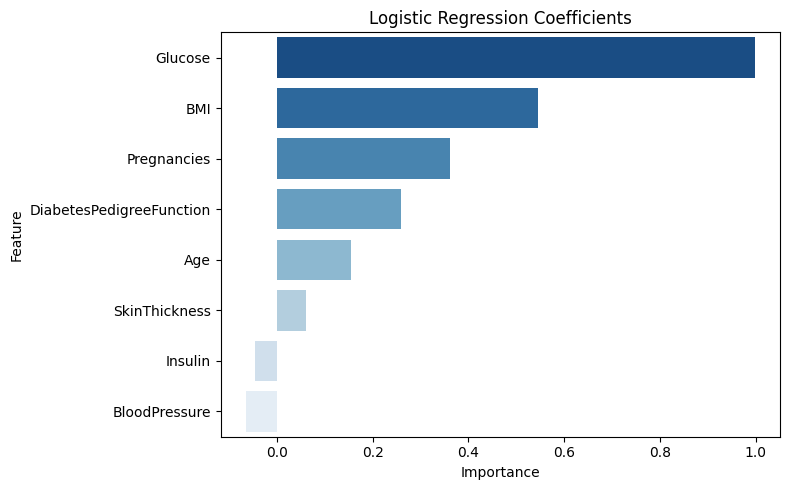

In [50]:
# Coefficients after scaling
feature_names = X.columns
coefs = final_model.best_estimator_.named_steps['clf'].coef_[0]
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefs
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Blues_r')
plt.title('Logistic Regression Coefficients')
plt.tight_layout()
plt.show()